# FICA Guardian: Agentic KYC Compliance System

**Domain:** South African Banking — Know Your Customer (KYC) / FICA Compliance  
**Architecture:** Agentic RAG with LangChain Middleware (>v1.0.0)  
**LLM:** Groq (llama-3.3-70b-versatile) with Ollama (llama3.2:3b) fallback  
**Purpose:** Reduce manual KYC processing time and improve regulatory accuracy  

---

## System Architecture

```
PDF Bundle (ID + KYC Form + PoR)
        |
        v
  Document Ingestion (PyMuPDF + pyzbar)
        |
        v
  RAG Vector Store (FAISS + sentence-transformers)
        |
        v
  Agentic KYC Engine
  +-----------------------------------------+
  | ModelFallbackMiddleware  (Groq -> Ollama)|
  | ModelCallLimitMiddleware (run_limit=12)  |
  | ToolRetryMiddleware      (backoff)       |
  | TodoListMiddleware       (gate planning) |
  | KYCAuditMiddleware       (audit trail)   |
  |                                         |
  |  Gate 1: Identity Integrity             |
  |  Gate 2: Residency & Recency            |
  |  Gate 3: Database Risk Screening        |
  +-----------------------------------------+
        |
        v
  Pydantic KYCVerdict (structured output)
        |
        v
  Professional Compliance Report
```

---

**Reference Date for All Recency Checks:** 2026-03-25

## Section 0: Configuration & Environment

In [1]:
# ---------------------------------------------------------------------------
# CONFIGURATION CELL
# All tuneable parameters are declared here. Modify this cell to adjust
# thresholds, model settings, and processing behaviour without touching
# downstream pipeline code.
# ---------------------------------------------------------------------------

import os
from datetime import date

# --- LLM Settings -----------------------------------------------------------
GROQ_MODEL          = "llama-3.3-70b-versatile"
OLLAMA_MODEL        = "llama3.2:3b"
LLM_TEMPERATURE     = 0

# --- Rate Limiting & Safety -------------------------------------------------
MODEL_CALL_RUN_LIMIT        = 12    # Max model calls per client invocation
CLIENT_PROCESSING_DELAY_SEC = 3     # Seconds to wait between client batches

# --- RAG Settings -----------------------------------------------------------
EMBEDDING_MODEL     = "all-MiniLM-L6-v2"
CHUNK_SIZE          = 512
CHUNK_OVERLAP       = 64
RETRIEVAL_TOP_K     = 4
FAISS_INDEX_PATH    = "./faiss_kyc_index"

# --- KYC Business Logic -----------------------------------------------------
REFERENCE_DATE              = date(2026, 3, 25)   # Regulatory reference date
POR_MAX_AGE_DAYS            = 90                  # PoR currency threshold
ADDRESS_FUZZY_THRESHOLD     = 75                  # Minimum rapidfuzz score (0-100)

# --- File Paths -------------------------------------------------------------
DATA_DIR            = "./data"
IDS_DIR             = os.path.join(DATA_DIR, "ids")
KYC_FORMS_DIR       = os.path.join(DATA_DIR, "kyc_forms")
PORS_DIR            = os.path.join(DATA_DIR, "pors")
LOOKUP_DB_PATH      = os.path.join(DATA_DIR, "lookup", "fica_compliance.db")
REPORT_OUTPUT_PATH  = "./fica_guardian_report.md"

# --- Client IDs to Process --------------------------------------------------
CLIENT_IDS = ["001", "002", "003", "004", "005"]

print("Configuration loaded.")
print(f"  Reference date : {REFERENCE_DATE}")
print(f"  Primary LLM    : {GROQ_MODEL} via Groq")
print(f"  Fallback LLM   : {OLLAMA_MODEL} via Ollama")
print(f"  Model call cap : {MODEL_CALL_RUN_LIMIT} per client")

Configuration loaded.
  Reference date : 2026-03-25
  Primary LLM    : llama-3.3-70b-versatile via Groq
  Fallback LLM   : llama3.2:3b via Ollama
  Model call cap : 12 per client


In [2]:
# ---------------------------------------------------------------------------
# DEPENDENCY IMPORTS
# All third-party imports are centralised here to surface missing packages
# early. Install via: uv add <package>
# ---------------------------------------------------------------------------

# Standard library
import re
import json
import time
import sqlite3
import logging
from pathlib import Path
from datetime import datetime, timedelta
from typing import Any, Callable, Optional
from dataclasses import dataclass, field

# PDF processing
import fitz                          # PyMuPDF
from pdf2image import convert_from_path
from pyzbar.pyzbar import decode as decode_barcode

# Data & fuzzy matching
import pandas as pd
import matplotlib.pyplot as plt
from rapidfuzz import fuzz

# LangChain core
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

# LangChain agents & middleware (>v1.0.0 API)
from langchain.agents import create_agent
from langchain.agents.middleware import (
    AgentMiddleware,
    ModelFallbackMiddleware,
    ModelCallLimitMiddleware,
    ToolRetryMiddleware,
    TodoListMiddleware,
)
from langchain.agents.middleware import (
    AgentState,
    ModelRequest,
    ModelResponse,
)

# LangGraph checkpointer (required by ModelCallLimitMiddleware)
from langgraph.checkpoint.memory import InMemorySaver

# LLM providers
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama

# RAG components
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Pydantic v2 for structured output
from pydantic import BaseModel, Field

# Environment
from dotenv import load_dotenv
load_dotenv()

logging.basicConfig(level=logging.WARNING)  # Suppress verbose LangChain debug logs
logger = logging.getLogger("fica_guardian")

print("All imports successful.")

All imports successful.


## Section 1: Document Ingestion Layer

In [13]:
# ---------------------------------------------------------------------------
# DOCUMENT INGESTION
# Handles three document types per client:
#   1. ID Document  - Smart ID card (2-page) or Green Book (1-page)
#   2. KYC Form     - Bank-issued customer data capture form
#   3. Proof of Residence (PoR) - Utility bill, bank statement, lease, etc.
#
# For Smart ID cards, page classification is performed before text extraction
# because the front/back scan order is not guaranteed.
#
# Barcode decoding uses pyzbar on a rasterised page image (pdf2image).
# ---------------------------------------------------------------------------

# Keywords that strongly indicate the front face of a Smart ID card
_SMART_ID_FRONT_KEYWORDS = [
    "SURNAME", "NAMES", "SEX", "NATIONALITY", "DATE OF BIRTH",
    "COUNTRY OF BIRTH", "CITIZEN", "IDENTITY NUMBER",
]

# Keywords that strongly indicate the back face of a Smart ID card
_SMART_ID_BACK_KEYWORDS = [
    "FINGERPRINT", "THUMBPRINT", "BARCODE", "DEPARTMENT OF HOME AFFAIRS",
]


def _extract_page_text(pdf_path: str, page_index: int) -> str:
    """Extract plain text from a single PDF page using PyMuPDF."""
    with fitz.open(pdf_path) as doc:
        print(f"_extract_page_text: pdf_path={pdf_path}, page_index={page_index}")
        text=doc[page_index].get_text("text")
        print(f"get_text:{text}")
        return doc[page_index].get_text("text").strip()


def _classify_smart_id_pages(page0_text: str, page1_text: str) -> tuple[int, int]:
    """
    Determine which page is the front and which is the back of a Smart ID card.

    Returns:
        (front_page_index, back_page_index) as a tuple of 0-based integers.
    """
    def score(text: str, keywords: list[str]) -> int:
        upper = text.upper()
        return sum(1 for kw in keywords if kw in upper)

    front_score_p0 = score(page0_text, _SMART_ID_FRONT_KEYWORDS)
    front_score_p1 = score(page1_text, _SMART_ID_FRONT_KEYWORDS)

    if front_score_p0 >= front_score_p1:
        return 0, 1  # page 0 is front, page 1 is back
    return 1, 0      # page 1 is front, page 0 is back


def _decode_pdf417_barcode(pdf_path: str, page_index: int) -> Optional[str]:
    """
    Rasterise a PDF page to a PIL image and attempt PDF417 barcode decoding.
    Returns the decoded string or None if no barcode is found.
    """
    try:
        images = convert_from_path(pdf_path, first_page=page_index + 1,
                                   last_page=page_index + 1, dpi=300)
        if not images:
            return None
        decoded = decode_barcode(images[0])
        if decoded:
            return decoded[0].data.decode("utf-8", errors="replace")
        return None
    except Exception as exc:
        logger.warning("Barcode decode failed for %s page %d: %s",
                       pdf_path, page_index, exc)
        return None


def ingest_id_document(client_id: str) -> dict:
    """
    Ingest and classify an ID document for a given client.

    Returns a structured dict with:
        - id_type      : 'smart_id' | 'green_book'
        - front_text   : OCR text from the front face
        - back_text    : OCR text from the back face (Smart ID only)
        - barcode_data : Decoded barcode string (Smart ID only)
        - full_text    : Concatenated text for RAG indexing
    """
    pdf_path = os.path.join(IDS_DIR, f"{client_id}_id.pdf")

    with fitz.open(pdf_path) as doc:
        page_count = len(doc)

    if page_count == 1:
        # Green Book: single-page document, no barcode check applicable
        text = _extract_page_text(pdf_path, 0)
        return {
            "id_type"     : "green_book",
            "front_text"  : text,
            "back_text"   : None,
            "barcode_data": None,
            "full_text"   : text,
        }

    # Smart ID: classify front vs back regardless of scan order
    page0_text = _extract_page_text(pdf_path, 0)
    page1_text = _extract_page_text(pdf_path, 1)
    front_idx, back_idx = _classify_smart_id_pages(page0_text, page1_text)

    front_text = page0_text if front_idx == 0 else page1_text
    back_text  = page1_text if back_idx == 1 else page0_text
    barcode    = _decode_pdf417_barcode(pdf_path, back_idx)

    return {
        "id_type"     : "smart_id",
        "front_text"  : front_text,
        "back_text"   : back_text,
        "barcode_data": barcode,
        "full_text"   : f"[FRONT]\n{front_text}\n[BACK]\n{back_text}",
    }


def ingest_kyc_form(client_id: str) -> dict:
    """Extract all text from a KYC form PDF."""
    pdf_path = os.path.join(KYC_FORMS_DIR, f"{client_id}_kyc_form.pdf")
    texts = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            texts.append(page.get_text("text"))
    return {"full_text": "\n".join(texts).strip()}


def ingest_por(client_id: str) -> dict:
    """Extract all text from a Proof of Residence PDF."""
    # PoR filename pattern differs from other docs (e.g. 002_por02.pdf)
    por_dir = Path(PORS_DIR)
    matches = sorted(por_dir.glob(f"{client_id}_por*.pdf"))
    if not matches:
        raise FileNotFoundError(f"No PoR found for client {client_id} in {PORS_DIR}")
    pdf_path = str(matches[0])
    texts = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            texts.append(page.get_text("text"))
    return {"full_text": "\n".join(texts).strip()}


def ingest_client_bundle(client_id: str) -> dict:
    """
    Ingest the full document bundle for a client.

    Returns a dict keyed by document type, ready for RAG indexing
    and gate check tool injection.
    """
    print(f"  [Ingest] Client {client_id}: loading documents...")
    bundle = {
        "client_id": client_id,
        "id_doc"   : ingest_id_document(client_id),
        "kyc_form" : ingest_kyc_form(client_id),
        "por"      : ingest_por(client_id),
    }
    print(f"  [Ingest] Client {client_id}: {bundle['id_doc']['id_type']} detected")
    return bundle


print("Document ingestion functions defined.")

Document ingestion functions defined.


In [15]:
# ---------------------------------------------------------------------------
# DEBUG CELL: PDF content inspection
# Run this before the ingestion pipeline to diagnose extraction issues.
# Remove or comment out before final submission.
# ---------------------------------------------------------------------------

import fitz
import os

def diagnose_pdf(pdf_path: str):
    """
    Inspect a PDF page-by-page to determine content type and best
    extraction strategy before committing to a text extraction method.
    """
    print(f"\nDiagnosing: {pdf_path}")
    print(f"  File exists: {os.path.exists(pdf_path)}")

    with fitz.open(pdf_path) as doc:
        print(f"  Page count : {len(doc)}")
        for i, page in enumerate(doc):
            # Attempt all extraction modes
            text_plain  = page.get_text("text").strip()
            text_blocks = page.get_text("blocks")
            text_words  = page.get_text("words")

            # Check for embedded images
            image_list  = page.get_images(full=True)

            # Check for vector drawings (text drawn as paths)
            drawings    = page.get_drawings()

            print(f"\n  --- Page {i} ---")
            print(f"    get_text('text') length : {len(text_plain)} chars")
            print(f"    get_text('blocks') count: {len(text_blocks)} blocks")
            print(f"    get_text('words')  count: {len(text_words)} words")
            print(f"    Embedded images         : {len(image_list)}")
            print(f"    Vector drawings         : {len(drawings)}")

            if text_plain:
                print(f"    First 200 chars: {text_plain[:200]!r}")
            elif text_blocks:
                print(f"    First block    : {text_blocks[0]!r}")
            elif image_list:
                print(f"    Image XRef     : {image_list[0]}")
                print(f"    => CONCLUSION  : Page is a rasterised image. OCR required.")
            else:
                print(f"    => CONCLUSION  : Empty page or unsupported content type.")

# Run on one ID and one KYC form to establish the pattern
diagnose_pdf("./data/ids/001_id.pdf")
diagnose_pdf("./data/kyc_forms/001_kyc_form.pdf")
diagnose_pdf("./data/pors/001_por01.pdf")


Diagnosing: ./data/ids/001_id.pdf
  File exists: True
  Page count : 2

  --- Page 0 ---
    get_text('text') length : 0 chars
    get_text('blocks') count: 0 blocks
    get_text('words')  count: 0 words
    Embedded images         : 1
    Vector drawings         : 0
    Image XRef     : (3, 0, 600, 380, 8, 'DeviceRGB', '', 'FormXob.030c3bbd361c8f428e3836f221ec7bf7', 'ASCII85Decode', 0)
    => CONCLUSION  : Page is a rasterised image. OCR required.

  --- Page 1 ---
    get_text('text') length : 0 chars
    get_text('blocks') count: 0 blocks
    get_text('words')  count: 0 words
    Embedded images         : 1
    Vector drawings         : 0
    Image XRef     : (5, 0, 600, 380, 8, 'DeviceRGB', '', 'FormXob.d05cc9b57ba44f43954ed67c179c8657', 'ASCII85Decode', 0)
    => CONCLUSION  : Page is a rasterised image. OCR required.

Diagnosing: ./data/kyc_forms/001_kyc_form.pdf
  File exists: True
  Page count : 1

  --- Page 0 ---
    get_text('text') length : 652 chars
    get_text('blocks')

In [14]:
bundle = ingest_client_bundle("001")
bundle

  [Ingest] Client 001: loading documents...
_extract_page_text: pdf_path=./data/ids/001_id.pdf, page_index=0
get_text:
_extract_page_text: pdf_path=./data/ids/001_id.pdf, page_index=1
get_text:
  [Ingest] Client 001: smart_id detected


{'client_id': '001',
 'id_doc': {'id_type': 'smart_id',
  'front_text': '',
  'back_text': '',
  'barcode_data': None,
  'full_text': '[FRONT]\n\n[BACK]\n'},
 'kyc_form': {'full_text': 'A\nAzania Digital Bank\nThe Future of African Finance\nDigital KYC Submission Form - Scenario 01\n1. PERSONAL INFORMATION\nFull Names:\nSipho Khumalo\nID / Passport Number:\n8004237456087\nResidential Address:\n45 Marshall St, Joburg, 2001\nNationality:\nSouth African\nDate of Birth:\n1980-04-23\n2. FINANCIAL INFORMATION\nEmployment Status:\nSoftware Engineer\nMonthly Income:\nZAR 65,000\nSource of Wealth:\nSalary\nExpected Monthly Volume:\nZAR 15,000\n3. DECLARATIONS\nPolitically Exposed Person (PEP):\nNo\nTax Residency:\nSouth Africa\nDeclaration of Honesty:\nI certify that all details are true and correct.\nAzania Digital Bank is a registered FSP. Confidential Submission.'},
 'por': {'full_text': 'CITY OF JOHANNESBURG\n158 Civic Boulevard, Braamfontein, 2001\nTAX INVOICE / MUNICIPAL STATEMENT\nCUSTOM

## Section 2: RAG Vector Store

In [4]:
# ---------------------------------------------------------------------------
# RAG VECTOR STORE
# Each client bundle is embedded into a per-session FAISS vector store.
# The agent retriever is used to pull relevant document passages when
# answering cross-document questions (e.g. address triangulation).
#
# Embedding model: all-MiniLM-L6-v2 (local, no API calls)
# Vector store: FAISS (persisted to disk per session)
# ---------------------------------------------------------------------------

_embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)
_splitter   = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)


def build_client_vectorstore(bundle: dict) -> FAISS:
    """
    Build a FAISS vector store for a single client bundle.

    Each document section is tagged with metadata (source, client_id)
    to support filtered retrieval during gate checks.
    """
    client_id = bundle["client_id"]
    raw_docs = [
        Document(
            page_content=bundle["id_doc"]["full_text"],
            metadata={"source": "id_document", "client_id": client_id},
        ),
        Document(
            page_content=bundle["kyc_form"]["full_text"],
            metadata={"source": "kyc_form", "client_id": client_id},
        ),
        Document(
            page_content=bundle["por"]["full_text"],
            metadata={"source": "por", "client_id": client_id},
        ),
    ]

    # Chunk documents preserving metadata
    chunks = _splitter.split_documents(raw_docs)
    vectorstore = FAISS.from_documents(chunks, _embeddings)

    # Persist to disk for reproducibility and audit
    index_path = f"{FAISS_INDEX_PATH}_{client_id}"
    vectorstore.save_local(index_path)
    print(f"  [RAG] Client {client_id}: {len(chunks)} chunks indexed -> {index_path}")
    return vectorstore


def load_client_vectorstore(client_id: str) -> FAISS:
    """Load a previously persisted FAISS index for a client."""
    index_path = f"{FAISS_INDEX_PATH}_{client_id}"
    return FAISS.load_local(index_path, _embeddings,
                            allow_dangerous_deserialization=True)


print("RAG vector store functions defined.")
print(f"  Embedding model: {EMBEDDING_MODEL}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAG vector store functions defined.
  Embedding model: all-MiniLM-L6-v2


## Section 3: KYC Gate Check Tools

In [5]:
# ---------------------------------------------------------------------------
# GATE 1: STRUCTURAL IDENTITY INTEGRITY TOOLS
#
# Each tool is a discrete, independently callable function decorated with
# @tool from langchain_core. The agent invokes these tools autonomously
# during its reasoning loop.
#
# Tool inputs are plain Python types (str, dict) to ensure broad LLM
# compatibility without requiring structured tool call schemas.
# ---------------------------------------------------------------------------

@tool
def validate_id_format_and_luhn(id_number: str) -> dict:
    """
    Gate 1.1 — Validate South African ID number format and Luhn checksum.

    Checks:
      - Exactly 13 numeric digits (regex: ^[0-9]{13}$)
      - Luhn algorithm validity (detects transcription errors and counterfeits)

    Returns:
        dict with 'format_valid', 'luhn_valid', 'status', 'reason'
    """
    id_clean = str(id_number).strip()

    # Format check
    format_valid = bool(re.match(r"^[0-9]{13}$", id_clean))
    if not format_valid:
        return {
            "format_valid": False,
            "luhn_valid"  : False,
            "status"      : "REJECTED",
            "reason"      : f"ID '{id_clean}' does not match 13-digit format.",
        }

    # Luhn algorithm
    digits = [int(d) for d in id_clean]
    total = 0
    for i, d in enumerate(reversed(digits)):
        if i % 2 == 1:  # Double every second digit from the right
            d *= 2
            if d > 9:
                d -= 9
        total += d
    luhn_valid = (total % 10 == 0)

    return {
        "format_valid": True,
        "luhn_valid"  : luhn_valid,
        "status"      : "PASS" if luhn_valid else "REJECTED",
        "reason"      : (
            "ID format valid and Luhn checksum confirmed."
            if luhn_valid else
            "Luhn checksum failed. Possible counterfeit ID."
        ),
    }


@tool
def cross_match_id_number(id_from_form: str, id_from_document: str) -> dict:
    """
    Gate 1.2 — Cross-match the ID number on the KYC form against the ID document.

    A data mismatch indicates either a data capture error or deliberate fraud.

    Returns:
        dict with 'match', 'status', 'reason'
    """
    id_form = str(id_from_form).strip().replace(" ", "")
    id_doc  = str(id_from_document).strip().replace(" ", "")
    match   = (id_form == id_doc)

    return {
        "match" : match,
        "status": "PASS" if match else "REJECTED",
        "reason": (
            "ID numbers match across KYC form and ID document."
            if match else
            f"Data mismatch: form has '{id_form}', ID document has '{id_doc}'."
        ),
    }


@tool
def smart_id_barcode_integrity_check(front_ocr_name: str,
                                     barcode_data: Optional[str],
                                     id_type: str) -> dict:
    """
    Gate 1.3 — Compare the name on the Smart ID front face against the back barcode.

    This check is only applicable to Smart ID cards. Green Book IDs return N/A.
    A name mismatch between the printed face and embedded barcode indicates
    identity tampering.

    Returns:
        dict with 'applicable', 'match', 'status', 'reason'
    """
    if id_type.lower() == "green_book":
        return {
            "applicable": False,
            "match"     : None,
            "status"    : "N/A",
            "reason"    : "Green Book ID: barcode integrity check not applicable.",
        }

    if not barcode_data:
        return {
            "applicable": True,
            "match"     : None,
            "status"    : "FLAG",
            "reason"    : "Smart ID: barcode could not be decoded. Manual review required.",
        }

    # Fuzzy match to tolerate minor OCR variations in the name
    score = fuzz.token_set_ratio(front_ocr_name.upper(), barcode_data.upper())
    match = score >= ADDRESS_FUZZY_THRESHOLD

    return {
        "applicable"   : True,
        "match"        : match,
        "fuzzy_score"  : score,
        "status"       : "PASS" if match else "CRITICAL_ALERT",
        "reason"       : (
            f"Front OCR name matches barcode data (score: {score})."
            if match else
            f"CRITICAL: Name mismatch between front face and barcode. "
            f"Identity tampering suspected (score: {score})."
        ),
    }


@tool
def validate_age_dob_consistency(id_number: str, dob_on_form: str) -> dict:
    """
    Gate 1.4 — Verify that the date of birth embedded in the ID number matches the KYC form.

    South African ID structure: YYMMDD SSSS C A Z
    The first 6 digits encode the date of birth.

    Args:
        id_number  : 13-digit SA ID number
        dob_on_form: Date of birth as recorded on the KYC form (YYYY-MM-DD or DD/MM/YYYY)

    Returns:
        dict with 'dob_from_id', 'dob_from_form', 'match', 'status', 'reason'
    """
    id_clean = str(id_number).strip()
    if not re.match(r"^[0-9]{13}$", id_clean):
        return {"status": "ERROR", "reason": "Invalid ID number passed to DOB check."}

    yy = int(id_clean[0:2])
    mm = int(id_clean[2:4])
    dd = int(id_clean[4:6])

    # Determine century: FICA considers > current year (26) as 1900s
    year = 1900 + yy if yy > 26 else 2000 + yy
    dob_from_id = f"{year:04d}-{mm:02d}-{dd:02d}"

    # Normalise form date to YYYY-MM-DD
    form_clean = str(dob_on_form).strip()
    try:
        if "/" in form_clean:
            d, m, y = form_clean.split("/")
            dob_normalised = f"{y}-{m.zfill(2)}-{d.zfill(2)}"
        else:
            dob_normalised = form_clean
    except Exception:
        dob_normalised = form_clean

    match = (dob_from_id == dob_normalised)
    return {
        "dob_from_id"  : dob_from_id,
        "dob_from_form": dob_normalised,
        "match"        : match,
        "status"       : "PASS" if match else "FLAG",
        "reason"       : (
            "Date of birth is consistent across ID number and KYC form."
            if match else
            f"DOB mismatch: ID encodes '{dob_from_id}', form states '{dob_normalised}'."
        ),
    }


print("Gate 1 tools defined: validate_id_format_and_luhn, cross_match_id_number,")
print("  smart_id_barcode_integrity_check, validate_age_dob_consistency")

Gate 1 tools defined: validate_id_format_and_luhn, cross_match_id_number,
  smart_id_barcode_integrity_check, validate_age_dob_consistency


In [6]:
# ---------------------------------------------------------------------------
# GATE 2: RESIDENCY & RECENCY TOOLS
# ---------------------------------------------------------------------------

@tool
def classify_por_document(por_text: str) -> dict:
    """
    Gate 2.1 — Classify the type of Proof of Residence document.

    Supported types:
        - utility_bill      : Water, electricity, rates, or similar municipal accounts
        - bank_statement    : Statement issued by a registered bank
        - lease_agreement   : Rental/lease contract with expiry date
        - saps_affidavit    : South African Police Service sworn affidavit
        - unknown           : Could not classify

    Returns:
        dict with 'doc_type', 'confidence', 'status', 'reason'
    """
    text_upper = por_text.upper()

    classification_rules = [
        ("utility_bill"   , ["MUNICIPALITY", "ESKOM", "WATER", "ELECTRICITY",
                              "RATES", "ACCOUNT NUMBER", "METER"]),
        ("bank_statement" , ["BANK STATEMENT", "BRANCH CODE", "ACCOUNT HOLDER",
                              "OPENING BALANCE", "CLOSING BALANCE", "TRANSACTION"]),
        ("lease_agreement", ["LEASE", "RENTAL AGREEMENT", "TENANT", "LANDLORD",
                              "EXPIRY DATE", "LEASE PERIOD"]),
        ("saps_affidavit" , ["SOUTH AFRICAN POLICE", "AFFIDAVIT", "SWORN",
                              "COMMISSIONER OF OATHS", "SAPS"]),
    ]

    scores = {}
    for doc_type, keywords in classification_rules:
        scores[doc_type] = sum(1 for kw in keywords if kw in text_upper)

    best_type  = max(scores, key=scores.get)
    best_score = scores[best_type]

    if best_score == 0:
        return {
            "doc_type"  : "unknown",
            "confidence": 0,
            "status"    : "FLAG",
            "reason"    : "PoR document type could not be classified.",
        }

    return {
        "doc_type"  : best_type,
        "confidence": best_score,
        "status"    : "PASS",
        "reason"    : f"Document classified as '{best_type}' with confidence score {best_score}.",
    }


@tool
def check_90_day_currency_rule(por_text: str, doc_type: str) -> dict:
    """
    Gate 2.2 — Verify that the PoR document is within the 90-day currency window.

    Reference date: 2026-03-25.
    For lease agreements, the expiry date must be in the future (not the issue date).

    Returns:
        dict with 'doc_date', 'days_old', 'within_90_days', 'status', 'reason'
    """
    # Pattern to detect dates in common South African document formats
    date_patterns = [
        (r"(\d{4})[-/](\d{2})[-/](\d{2})", "%Y-%m-%d"),  # YYYY-MM-DD
        (r"(\d{2})[-/](\d{2})[-/](\d{4})", "%d-%m-%Y"),  # DD-MM-YYYY
        (r"(\d{1,2})\s+([A-Za-z]+)\s+(\d{4})", None),    # DD Month YYYY
    ]

    months = {"january":1,"february":2,"march":3,"april":4,"may":5,"june":6,
              "july":7,"august":8,"september":9,"october":10,"november":11,"december":12}

    found_dates = []

    # Extract YYYY-MM-DD and DD-MM-YYYY patterns
    for pattern, fmt in date_patterns[:2]:
        for m in re.finditer(pattern, por_text):
            try:
                found_dates.append(datetime.strptime(m.group(0).replace("/","-"), fmt).date())
            except ValueError:
                pass

    # Extract DD Month YYYY patterns
    for m in re.finditer(r"(\d{1,2})\s+([A-Za-z]+)\s+(\d{4})", por_text):
        try:
            day  = int(m.group(1))
            mon  = months.get(m.group(2).lower())
            year = int(m.group(3))
            if mon:
                found_dates.append(date(year, mon, day))
        except (ValueError, TypeError):
            pass

    if not found_dates:
        return {
            "doc_date"      : None,
            "days_old"      : None,
            "within_90_days": False,
            "status"        : "FLAG",
            "reason"        : "No valid date found in PoR document. Manual review required.",
        }

    if doc_type == "lease_agreement":
        # For leases, use the latest date found (expiry date)
        relevant_date = max(found_dates)
        is_valid = relevant_date > REFERENCE_DATE
        return {
            "doc_date"      : str(relevant_date),
            "days_old"      : (REFERENCE_DATE - relevant_date).days,
            "within_90_days": is_valid,
            "status"        : "PASS" if is_valid else "REJECTED",
            "reason"        : (
                f"Lease agreement expiry {relevant_date} is in the future."
                if is_valid else
                f"Lease agreement expired on {relevant_date}."
            ),
        }

    # For other doc types, use the most recent date (issue/statement date)
    relevant_date = max(found_dates)
    days_old = (REFERENCE_DATE - relevant_date).days
    within_90 = days_old <= POR_MAX_AGE_DAYS

    return {
        "doc_date"      : str(relevant_date),
        "days_old"      : days_old,
        "within_90_days": within_90,
        "status"        : "PASS" if within_90 else "REJECTED",
        "reason"        : (
            f"PoR dated {relevant_date} is {days_old} days old (within 90-day limit)."
            if within_90 else
            f"PoR dated {relevant_date} is {days_old} days old. EXCEEDS 90-day limit."
        ),
    }


@tool
def check_physicality_of_address(por_text: str) -> dict:
    """
    Gate 2.3 — Reject PoR documents where the address is only a PO Box.

    FICA requires a physical street address for residential verification.
    PO Boxes are not acceptable as proof of physical residence.

    Returns:
        dict with 'is_po_box', 'has_street_address', 'status', 'reason'
    """
    text_upper = por_text.upper()
    is_po_box = bool(re.search(r"\bP\.?O\.?\s*BOX\b", text_upper))

    # Check for presence of a street-type indicator
    street_indicators = [
        r"\b\d+\s+[A-Z][A-Z\s]+(?:STREET|ST|ROAD|RD|AVENUE|AVE|DRIVE|DR|"
        r"CLOSE|CL|LANE|LN|CRESCENT|CR|BOULEVARD|BLVD|PLACE|PL|COURT|CT)\b"
    ]
    has_street = any(re.search(p, text_upper) for p in street_indicators)

    # Only reject if it is EXCLUSIVELY a PO Box with no street address
    reject = is_po_box and not has_street

    return {
        "is_po_box"        : is_po_box,
        "has_street_address": has_street,
        "status"           : "REJECTED" if reject else "PASS",
        "reason"           : (
            "PoR contains only a PO Box. Physical street address required by FICA."
            if reject else
            "Physical street address confirmed in PoR document."
        ),
    }


@tool
def fuzzy_address_triangulation(address_on_form: str, address_on_por: str) -> dict:
    """
    Gate 2.4 — Fuzzy match the residential address on the KYC form against the PoR.

    Uses rapidfuzz token_set_ratio to tolerate abbreviations and ordering differences
    (e.g. 'Str' vs 'Street', '10 Main' vs 'Main Street 10').

    Returns:
        dict with 'score', 'threshold', 'match', 'status', 'reason'
    """
    score = fuzz.token_set_ratio(address_on_form.upper(), address_on_por.upper())
    match = score >= ADDRESS_FUZZY_THRESHOLD

    return {
        "score"    : score,
        "threshold": ADDRESS_FUZZY_THRESHOLD,
        "match"    : match,
        "status"   : "PASS" if match else "FLAG",
        "reason"   : (
            f"Addresses are consistent (fuzzy score: {score}/{ADDRESS_FUZZY_THRESHOLD})."
            if match else
            f"Address mismatch detected (fuzzy score: {score}/{ADDRESS_FUZZY_THRESHOLD}). "
            "Manual review recommended."
        ),
    }


print("Gate 2 tools defined: classify_por_document, check_90_day_currency_rule,")
print("  check_physicality_of_address, fuzzy_address_triangulation")

Gate 2 tools defined: classify_por_document, check_90_day_currency_rule,
  check_physicality_of_address, fuzzy_address_triangulation


In [7]:
# ---------------------------------------------------------------------------
# GATE 3: DATABASE RISK SCREENING TOOLS
#
# All lookups target the SQLite database at LOOKUP_DB_PATH.
# Connection is opened and closed per call to avoid long-lived connections
# during the agent loop.
# ---------------------------------------------------------------------------

def _db_query(sql: str, params: tuple) -> list[dict]:
    """
    Execute a parameterised query against the FICA compliance database.
    Returns a list of row dicts. Raises on connection or query failure.
    """
    with sqlite3.connect(LOOKUP_DB_PATH) as conn:
        conn.row_factory = sqlite3.Row
        cursor = conn.execute(sql, params)
        return [dict(row) for row in cursor.fetchall()]


@tool
def sanctions_list_lookup(id_number: str) -> dict:
    """
    Gate 3.1 — Query the sanctions_list table by ID number.

    Any sanctions hit results in immediate rejection regardless of other gate outcomes.
    Sanctions screening is a mandatory AML control under FICA Section 28.

    Returns:
        dict with 'hit', 'records', 'status', 'reason'
    """
    try:
        rows = _db_query(
            "SELECT full_name, id_number, risk_level, reason "
            "FROM sanctions_list WHERE id_number = ?",
            (str(id_number).strip(),)
        )
        hit = len(rows) > 0
        return {
            "hit"    : hit,
            "records": rows,
            "status" : "REJECTED" if hit else "PASS",
            "reason" : (
                f"SANCTIONS HIT: {rows[0]['full_name']} — {rows[0]['reason']}"
                if hit else
                "No sanctions match found for this ID number."
            ),
        }
    except Exception as exc:
        return {"hit": None, "status": "ERROR", "reason": str(exc)}


@tool
def pep_registry_lookup(full_name: str) -> dict:
    """
    Gate 3.2 — Query the pep_registry table by full name.

    A PEP (Politically Exposed Person) match triggers Enhanced Due素质 Diligence (EDD).
    The client is not rejected but flagged for additional scrutiny per FATF guidelines.

    Returns:
        dict with 'hit', 'is_active', 'position', 'status', 'reason'
    """
    try:
        # Use LIKE for partial name matching to tolerate middle name omissions
        name_parts = str(full_name).strip().split()
        if not name_parts:
            return {"hit": False, "status": "PASS", "reason": "No name provided."}

        surname = name_parts[-1]
        rows = _db_query(
            "SELECT full_name, id_number, position, is_active "
            "FROM pep_registry WHERE full_name LIKE ?",
            (f"%{surname}%",)
        )

        # Secondary filter: check first name also matches
        if rows and len(name_parts) > 1:
            first = name_parts[0].upper()
            rows = [r for r in rows if first in r["full_name"].upper()]

        hit = len(rows) > 0
        if hit:
            record = rows[0]
            return {
                "hit"      : True,
                "is_active": record["is_active"],
                "position" : record["position"],
                "status"   : "FLAG_EDD",
                "reason"   : (
                    f"PEP MATCH: {record['full_name']} — Position: {record['position']}. "
                    "Enhanced Due Diligence required."
                ),
            }

        return {
            "hit"      : False,
            "is_active": None,
            "position" : None,
            "status"   : "PASS",
            "reason"   : "No PEP registry match found for this name.",
        }
    except Exception as exc:
        return {"hit": None, "status": "ERROR", "reason": str(exc)}


@tool
def bank_reference_check(branch_code: str, doc_type: str) -> dict:
    """
    Gate 3.3 — Validate a bank branch code if the PoR is a bank statement.

    Only applicable when the PoR has been classified as a bank statement.
    An unrecognised branch code may indicate a fraudulent statement.

    Returns:
        dict with 'applicable', 'bank_name', 'valid', 'status', 'reason'
    """
    if doc_type != "bank_statement":
        return {
            "applicable": False,
            "status"    : "N/A",
            "reason"    : f"PoR is '{doc_type}'. Bank reference check not applicable.",
        }

    try:
        code_clean = str(branch_code).strip().replace(" ", "")
        rows = _db_query(
            "SELECT bank_name, branch_code FROM bank_reference WHERE branch_code = ?",
            (code_clean,)
        )
        valid = len(rows) > 0
        return {
            "applicable": True,
            "bank_name" : rows[0]["bank_name"] if valid else None,
            "valid"     : valid,
            "status"    : "PASS" if valid else "FLAG",
            "reason"    : (
                f"Branch code {code_clean} confirmed: {rows[0]['bank_name']}."
                if valid else
                f"Branch code {code_clean} not found in registered bank reference table."
            ),
        }
    except Exception as exc:
        return {"applicable": True, "valid": None, "status": "ERROR", "reason": str(exc)}


print("Gate 3 tools defined: sanctions_list_lookup, pep_registry_lookup, bank_reference_check")

Gate 3 tools defined: sanctions_list_lookup, pep_registry_lookup, bank_reference_check


In [8]:
# ---------------------------------------------------------------------------
# TOOL REGISTRY
# Aggregate all gate tools into a single list for agent registration.
# ---------------------------------------------------------------------------

KYC_TOOLS = [
    # Gate 1
    validate_id_format_and_luhn,
    cross_match_id_number,
    smart_id_barcode_integrity_check,
    validate_age_dob_consistency,
    # Gate 2
    classify_por_document,
    check_90_day_currency_rule,
    check_physicality_of_address,
    fuzzy_address_triangulation,
    # Gate 3
    sanctions_list_lookup,
    pep_registry_lookup,
    bank_reference_check,
]

print(f"Tool registry: {len(KYC_TOOLS)} tools registered across 3 gates.")

Tool registry: 11 tools registered across 3 gates.


## Section 4: LangChain Middleware & Agent Construction

In [9]:
# ---------------------------------------------------------------------------
# CUSTOM MIDDLEWARE: KYCAuditMiddleware
#
# Implements the LangChain >v1.0.0 AgentMiddleware interface using the
# verified decorator-based lifecycle hooks:
#
#   before_agent  -> initialise per-client audit record
#   after_agent   -> finalise audit record with wall-clock time
#   before_model  -> record model call start timestamp
#   after_model   -> capture token usage and active LLM identity
#   wrap_tool_call-> time each gate check and log pass/fail verdicts
#
# The class-based pattern is used (not standalone @decorator functions)
# because the audit log requires shared mutable state across multiple hooks.
# ---------------------------------------------------------------------------

class KYCAuditMiddleware(AgentMiddleware):
    """
    Lifecycle middleware that produces a structured audit trail for each
    KYC client invocation.

    Captures:
        - Per-model-call token usage (input, output, total)
        - Which LLM served each request (Groq vs Ollama fallback)
        - Per-tool-call gate verdicts and latency
        - Total agent wall-clock time

    The populated audit_records list is accessed after all clients are
    processed to generate the analytics section.
    """

    def __init__(self):
        self.audit_records: list[dict] = []
        self._current: dict = {}          # Active client record during agent run
        self._model_call_start: float = 0.0

    def before_agent(self, state: AgentState, runtime) -> dict | None:
        """
        Initialise a fresh audit record for the incoming client.
        Extracts client_id from the first HumanMessage in the state.
        """
        # Attempt to extract client_id from the agent input message
        client_id = "unknown"
        messages = state.get("messages", [])
        if messages:
            content = str(messages[0].content)
            match = re.search(r"client[_\s]?id[:\s]+([0-9]{3})", content, re.IGNORECASE)
            if match:
                client_id = match.group(1)

        self._current = {
            "client_id"         : client_id,
            "agent_start_time"  : time.time(),
            "model_calls"       : [],
            "tool_calls"        : [],
            "total_input_tokens": 0,
            "total_output_tokens": 0,
            "total_tokens"      : 0,
            "wall_clock_sec"    : None,
        }
        return None  # Continue normal execution

    def after_agent(self, state: AgentState, runtime) -> dict | None:
        """Finalise the audit record and append to the session log."""
        if self._current:
            self._current["wall_clock_sec"] = round(
                time.time() - self._current["agent_start_time"], 2
            )
            self.audit_records.append(dict(self._current))
            self._current = {}
        return None

    def before_model(self, state: AgentState, runtime) -> dict | None:
        """Record the start timestamp immediately before a model invocation."""
        self._model_call_start = time.time()
        return None

    def after_model(self, state: AgentState, runtime) -> dict | None:
        """
        Capture token usage from the last AI message after a model call.

        LangChain >v1.0.0 stores usage metadata in AIMessage.usage_metadata:
            {'input_tokens': int, 'output_tokens': int, 'total_tokens': int}
        The model ID is available in AIMessage.response_metadata['model'].
        """
        latency_ms = round((time.time() - self._model_call_start) * 1000)
        messages   = state.get("messages", [])
        call_record = {"latency_ms": latency_ms, "model": "unknown",
                       "input_tokens": 0, "output_tokens": 0, "total_tokens": 0}

        # Find the last AIMessage to extract usage metadata
        from langchain_core.messages import AIMessage
        for msg in reversed(messages):
            if isinstance(msg, AIMessage):
                usage = getattr(msg, "usage_metadata", {}) or {}
                call_record["input_tokens"]  = usage.get("input_tokens", 0)
                call_record["output_tokens"] = usage.get("output_tokens", 0)
                call_record["total_tokens"]  = usage.get("total_tokens", 0)
                resp_meta = getattr(msg, "response_metadata", {}) or {}
                call_record["model"] = resp_meta.get("model", "unknown")
                break

        if self._current:
            self._current["model_calls"].append(call_record)
            self._current["total_input_tokens"]  += call_record["input_tokens"]
            self._current["total_output_tokens"] += call_record["output_tokens"]
            self._current["total_tokens"]        += call_record["total_tokens"]
        return None

    def wrap_tool_call(self, request, handler: Callable) -> Any:
        """
        Wrap each KYC gate tool call to capture name, latency, and verdict.

        The handler callback represents all inner middleware layers.
        This follows the wrap_tool_call contract: call handler(request) and
        return its result, adding instrumentation around it.
        """
        tool_name  = getattr(request, "name", "unknown_tool")
        start_time = time.time()

        result = handler(request)  # Execute the actual tool

        latency_ms = round((time.time() - start_time) * 1000)

        # Attempt to extract a status verdict from the tool output
        verdict = "UNKNOWN"
        try:
            # Tool results arrive as ToolMessage; content may be JSON
            content = getattr(result, "content", "{}")
            parsed  = json.loads(content) if isinstance(content, str) else content
            verdict = parsed.get("status", "UNKNOWN") if isinstance(parsed, dict) else "UNKNOWN"
        except (json.JSONDecodeError, AttributeError):
            pass

        tool_record = {
            "tool"      : tool_name,
            "verdict"   : verdict,
            "latency_ms": latency_ms,
        }

        if self._current:
            self._current["tool_calls"].append(tool_record)

        return result


print("KYCAuditMiddleware defined with hooks: before_agent, after_agent,")
print("  before_model, after_model, wrap_tool_call")

KYCAuditMiddleware defined with hooks: before_agent, after_agent,
  before_model, after_model, wrap_tool_call


In [10]:
# ---------------------------------------------------------------------------
# SYSTEM PROMPTS
# ---------------------------------------------------------------------------

FICA_SYSTEM_PROMPT = """
You are FICA Guardian, a specialist KYC compliance verification agent operating
under the South African Financial Intelligence Centre Act (FICA) and the Financial
Action Task Force (FATF) Recommendations.

Your mandate is to verify client identity documentation with zero tolerance for
ambiguity. You must execute all gate checks in sequence using the available tools.
Do not infer or assume results — every check must be backed by a tool call.

REFERENCE DATE: 2026-03-25

GATE EXECUTION ORDER:
  Gate 1 (Identity Integrity): validate_id_format_and_luhn -> cross_match_id_number
    -> smart_id_barcode_integrity_check -> validate_age_dob_consistency
  Gate 2 (Residency & Recency): classify_por_document -> check_90_day_currency_rule
    -> check_physicality_of_address -> fuzzy_address_triangulation
  Gate 3 (Risk Screening): sanctions_list_lookup -> pep_registry_lookup
    -> bank_reference_check

VERDICT DECISION LOGIC:
  APPROVED     : All gate checks pass with no flags.
  REJECTED     : Any single check returns REJECTED status.
  CRITICAL_ALERT: Barcode name mismatch on Smart ID (identity tampering suspected).
  FLAG_EDD     : PEP registry hit — Enhanced Due Diligence required.
  MANUAL_REVIEW: Unresolvable flag (e.g. PO Box + no street address, unreadable barcode).

OUTPUT FORMAT:
Return a single JSON object with this exact structure:
{{
  "client_id": "<id>",
  "final_verdict": "<APPROVED|REJECTED|CRITICAL_ALERT|FLAG_EDD|MANUAL_REVIEW>",
  "risk_level": "<LOW|MEDIUM|HIGH|CRITICAL>",
  "gate_results": {{
    "gate_1": {{"status": "<PASS|FAIL>", "findings": ["...", "..."]}},
    "gate_2": {{"status": "<PASS|FAIL>", "findings": ["...", "..."]}},
    "gate_3": {{"status": "<PASS|FAIL>", "findings": ["...", "..."]}}
  }},
  "recommended_action": "<specific action for compliance officer>",
  "audit_timestamp": "<ISO-8601 datetime>"
}}

Do not include any text outside the JSON object in your final response.
"""

FICA_TODO_PROMPT = """
You are operating as a FICA compliance verification agent. Before processing any
client bundle, use write_todos to record all required gate checks as a structured
compliance task list. This todo list is your auditable gate completion register.

Required todos to register at the start of each client:
  [Gate 1.1] Validate 13-digit ID format and Luhn checksum
  [Gate 1.2] Cross-match ID number across KYC form and ID document
  [Gate 1.3] Smart ID barcode integrity check (front OCR vs back barcode)
  [Gate 1.4] Validate age/DOB consistency between ID number and KYC form
  [Gate 2.1] Classify proof of residence document type
  [Gate 2.2] Apply 90-day currency rule (reference: 2026-03-25)
  [Gate 2.3] Physicality check — reject PO Box-only addresses
  [Gate 2.4] Fuzzy address triangulation: KYC form vs PoR
  [Gate 3.1] Sanctions list lookup by ID number
  [Gate 3.2] PEP registry lookup by full name
  [Gate 3.3] Bank reference check (if PoR is a bank statement)

Mark each todo complete immediately after its corresponding tool call returns.
Do not proceed to the final verdict until all applicable todos are marked complete.
This ensures a fully auditable and FICA-compliant verification trail.
"""

print("System prompts defined.")

System prompts defined.


In [ ]:
# ---------------------------------------------------------------------------
# LLM INITIALISATION
# Groq (primary) and Ollama (fallback) are instantiated here.
# The GROQ_API_KEY is loaded from the .env file via python-dotenv.
# ---------------------------------------------------------------------------

groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key:
    raise EnvironmentError(
        "GROQ_API_KEY not found in environment. "
        "Add it to your .env file: GROQ_API_KEY=<your-key>"
    )

primary_llm = ChatOllama(
    model=OLLAMA_MODEL,
    temperature=LLM_TEMPERATURE,
)

fallback_llm = ChatGroq(
    model=GROQ_MODEL,
    temperature=LLM_TEMPERATURE,
    groq_api_key=groq_api_key,
)


print(f"Primary LLM  : {OLLAMA_MODEL} (Ollama)")
print(f"Fallback LLM : {GROQ_MODEL} (Groq)")

Primary LLM  : llama-3.3-70b-versatile (Groq)
Fallback LLM : llama3.2:3b (Ollama)


In [12]:
# ---------------------------------------------------------------------------
# AGENT CONSTRUCTION
#
# Middleware stack (applied in order, outermost to innermost):
#
#   1. ModelFallbackMiddleware  — Transparently falls back to Ollama if Groq
#                                 raises a rate limit or API error.
#
#   2. ModelCallLimitMiddleware — Hard ceiling of MODEL_CALL_RUN_LIMIT model
#                                 calls per client run. Prevents runaway agents
#                                 from exhausting the daily Groq quota.
#
#   3. ToolRetryMiddleware      — Automatically retries failed tool calls with
#                                 exponential backoff. Handles transient PDF
#                                 parse failures and SQLite lock contention.
#
#   4. TodoListMiddleware       — Equips the agent with write_todos/read_todos
#                                 tools and injects FICA gate planning instructions.
#                                 Produces a machine-readable gate completion
#                                 register that doubles as an audit trail.
#
#   5. KYCAuditMiddleware       — Custom lifecycle hooks for token analytics,
#                                 LLM identity logging, and gate verdict capture.
#
# InMemorySaver is required by ModelCallLimitMiddleware for state persistence.
# ---------------------------------------------------------------------------

audit_middleware = KYCAuditMiddleware()

kyc_agent = create_agent(
    model=primary_llm,
    tools=KYC_TOOLS,
    system_prompt=FICA_SYSTEM_PROMPT,
    checkpointer=InMemorySaver(),
    middleware=[
        ModelFallbackMiddleware(fallback_llm),
        ModelCallLimitMiddleware(run_limit=MODEL_CALL_RUN_LIMIT, exit_behavior="end"),
        ToolRetryMiddleware(),
        TodoListMiddleware(system_prompt=FICA_TODO_PROMPT),
        audit_middleware,
    ],
)

print("KYC agent constructed with 5-layer middleware stack.")
print(f"  Tool count    : {len(KYC_TOOLS)}")
print(f"  Model call cap: {MODEL_CALL_RUN_LIMIT} per client run")

KYC agent constructed with 5-layer middleware stack.
  Tool count    : 11
  Model call cap: 12 per client run


## Section 5: Structured Output & JSON Parser

In [13]:
# ---------------------------------------------------------------------------
# PYDANTIC v2 STRUCTURED OUTPUT: KYCVerdict
#
# Enforces a typed schema on the agent's final JSON output.
# A two-pass parser is used defensively because local LLMs occasionally
# prefix JSON with prose or wrap it in markdown code fences.
# ---------------------------------------------------------------------------

class GateResult(BaseModel):
    """Result summary for a single KYC gate."""
    status  : str         = Field(description="PASS or FAIL")
    findings: list[str]   = Field(description="List of check outcomes for this gate")


class KYCVerdict(BaseModel):
    """Structured final verdict output from the FICA Guardian agent."""
    client_id          : str                    = Field(description="Client identifier")
    final_verdict      : str                    = Field(
        description="APPROVED | REJECTED | CRITICAL_ALERT | FLAG_EDD | MANUAL_REVIEW"
    )
    risk_level         : str                    = Field(description="LOW | MEDIUM | HIGH | CRITICAL")
    gate_results       : dict[str, GateResult]  = Field(description="Per-gate outcomes")
    recommended_action : str                    = Field(description="Action for compliance officer")
    audit_timestamp    : str                    = Field(description="ISO-8601 datetime")


def _extract_json_from_llm_output(raw: str) -> str:
    """
    Two-pass JSON extraction to handle LLM prose prefixes and markdown fences.

    Pass 1: Strip markdown code fences (```json ... ```) if present.
    Pass 2: Locate the outermost JSON object using brace counting.
    """
    # Pass 1: strip code fences
    fence_match = re.search(r"```(?:json)?\s*([\s\S]+?)```", raw, re.IGNORECASE)
    if fence_match:
        return fence_match.group(1).strip()

    # Pass 2: find outermost JSON object
    start = raw.find("{")
    if start == -1:
        raise ValueError(f"No JSON object found in LLM output:\n{raw[:300]}")

    depth, end = 0, start
    for i, ch in enumerate(raw[start:], start):
        if ch == "{": depth += 1
        elif ch == "}": depth -= 1
        if depth == 0:
            end = i
            break
    return raw[start:end + 1]


def parse_agent_verdict(agent_output: dict, client_id: str) -> KYCVerdict:
    """
    Extract and validate the KYCVerdict from the raw agent invocation output.

    Searches all messages in the agent output for the final AI response
    containing a valid JSON verdict, then validates it against KYCVerdict.
    Falls back to a MANUAL_REVIEW verdict if parsing fails.
    """
    from langchain_core.messages import AIMessage

    messages = agent_output.get("messages", [])

    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and msg.content:
            try:
                json_str = _extract_json_from_llm_output(str(msg.content))
                data     = json.loads(json_str)
                # Ensure client_id is set correctly
                data.setdefault("client_id", client_id)
                data.setdefault("audit_timestamp", datetime.now().isoformat())
                return KYCVerdict(**data)
            except Exception as parse_err:
                logger.debug("Verdict parse attempt failed: %s", parse_err)
                continue

    # Fallback: return a safe default verdict if no valid JSON was found
    logger.warning("Client %s: could not parse verdict from agent output.", client_id)
    return KYCVerdict(
        client_id         =client_id,
        final_verdict     ="MANUAL_REVIEW",
        risk_level        ="HIGH",
        gate_results      ={"gate_1": GateResult(status="UNKNOWN", findings=["Parse failure"]),
                            "gate_2": GateResult(status="UNKNOWN", findings=["Parse failure"]),
                            "gate_3": GateResult(status="UNKNOWN", findings=["Parse failure"])},
        recommended_action="Agent output could not be parsed. Manual officer review required.",
        audit_timestamp   =datetime.now().isoformat(),
    )


print("Pydantic v2 KYCVerdict schema and two-pass JSON parser defined.")

Pydantic v2 KYCVerdict schema and two-pass JSON parser defined.


## Section 6: Client Processing Pipeline

In [14]:
# ---------------------------------------------------------------------------
# CLIENT PROCESSING PIPELINE
#
# For each client:
#   1. Ingest the 3-document bundle (ID + KYC form + PoR)
#   2. Build a per-client FAISS vector store
#   3. Construct a context-rich HumanMessage for the agent
#   4. Invoke the agent (blocking; synchronous for notebook compatibility)
#   5. Parse the structured KYCVerdict
#   6. Collect results for the report section
#
# A configurable delay between clients prevents Groq rate limit breaches.
# ---------------------------------------------------------------------------

def build_agent_prompt(client_id: str, bundle: dict) -> str:
    """
    Construct the full context prompt for the KYC agent.

    Embeds all extracted document text directly into the prompt so the agent
    can extract field values (ID number, name, address, dates) without
    requiring a separate retrieval step for known fields.

    The RAG retriever remains available for nuanced cross-document queries.
    """
    id_doc   = bundle["id_doc"]
    kyc_form = bundle["kyc_form"]
    por      = bundle["por"]

    barcode_section = (
        f"BARCODE DECODED DATA:\n{id_doc['barcode_data']}\n"
        if id_doc.get("barcode_data")
        else "BARCODE DECODED DATA: Not available or not applicable.\n"
    )

    return f"""
Process KYC verification for Client ID: {client_id}

=== ID DOCUMENT ({id_doc['id_type'].upper().replace('_', ' ')}) ===
{id_doc['full_text']}

{barcode_section}
=== KYC FORM ===
{kyc_form['full_text']}

=== PROOF OF RESIDENCE ===
{por['full_text']}

Execute all three gate checks using the available tools in sequence.
Extract field values (ID number, name, DOB, address, branch code) from the
document text above before calling each tool. Return the final verdict as
a single JSON object conforming to the KYCVerdict schema.
""".strip()


def process_client(client_id: str) -> tuple[KYCVerdict, dict]:
    """
    Execute the full KYC verification pipeline for one client.

    Returns:
        (KYCVerdict, bundle) — the structured verdict and raw document bundle.
    """
    print(f"\n{'='*60}")
    print(f"  Processing Client {client_id}")
    print(f"{'='*60}")

    # Step 1: Ingest documents
    bundle = ingest_client_bundle(client_id)

    # Step 2: Build RAG vector store (persisted to disk)
    build_client_vectorstore(bundle)

    # Step 3: Build agent prompt
    prompt = build_agent_prompt(client_id, bundle)

    # Step 4: Invoke agent
    print(f"  [Agent] Invoking KYC verification...")
    thread_config = {"configurable": {"thread_id": f"kyc_client_{client_id}"}}

    agent_output = kyc_agent.invoke(
        {"messages": [HumanMessage(content=prompt)]},
        config=thread_config,
    )

    # Step 5: Parse structured verdict
    verdict = parse_agent_verdict(agent_output, client_id)
    print(f"  [Verdict] {verdict.final_verdict} | Risk: {verdict.risk_level}")

    return verdict, bundle


# --- Main Processing Loop ---------------------------------------------------

all_verdicts: list[KYCVerdict] = []
all_bundles : list[dict]       = []

for idx, client_id in enumerate(CLIENT_IDS):
    verdict, bundle = process_client(client_id)
    all_verdicts.append(verdict)
    all_bundles.append(bundle)

    # Rate limit protection: pause between clients (skip after last)
    if idx < len(CLIENT_IDS) - 1:
        print(f"  [Rate Limit] Pausing {CLIENT_PROCESSING_DELAY_SEC}s before next client...")
        time.sleep(CLIENT_PROCESSING_DELAY_SEC)

print(f"\nProcessing complete. {len(all_verdicts)} clients verified.")


  Processing Client 001
  [Ingest] Client 001: loading documents...
  [Ingest] Client 001: smart_id detected
  [RAG] Client 001: 4 chunks indexed -> ./faiss_kyc_index_001
  [Agent] Invoking KYC verification...
  [Verdict] CRITICAL_ALERT | Risk: CRITICAL
  [Rate Limit] Pausing 3s before next client...

  Processing Client 002
  [Ingest] Client 002: loading documents...
  [Ingest] Client 002: green_book detected
  [RAG] Client 002: 3 chunks indexed -> ./faiss_kyc_index_002
  [Agent] Invoking KYC verification...


  [Verdict] MANUAL_REVIEW | Risk: HIGH
  [Rate Limit] Pausing 3s before next client...

  Processing Client 003
  [Ingest] Client 003: loading documents...
  [Ingest] Client 003: smart_id detected
  [RAG] Client 003: 4 chunks indexed -> ./faiss_kyc_index_003
  [Agent] Invoking KYC verification...


  [Verdict] MANUAL_REVIEW | Risk: HIGH
  [Rate Limit] Pausing 3s before next client...

  Processing Client 004
  [Ingest] Client 004: loading documents...
  [Ingest] Client 004: smart_id detected
  [RAG] Client 004: 4 chunks indexed -> ./faiss_kyc_index_004
  [Agent] Invoking KYC verification...


  [Verdict] MANUAL_REVIEW | Risk: HIGH
  [Rate Limit] Pausing 3s before next client...

  Processing Client 005
  [Ingest] Client 005: loading documents...
  [Ingest] Client 005: smart_id detected
  [RAG] Client 005: 4 chunks indexed -> ./faiss_kyc_index_005
  [Agent] Invoking KYC verification...
  [Verdict] MANUAL_REVIEW | Risk: LOW

Processing complete. 5 clients verified.


## Section 7: Compliance Report Generation

In [15]:
# ---------------------------------------------------------------------------
# REPORT GENERATION
#
# Produces a structured Markdown compliance report covering:
#   - Executive summary table (all 5 clients)
#   - Per-client detail section (gate results + recommended action)
#   - Report written to REPORT_OUTPUT_PATH for record keeping
# ---------------------------------------------------------------------------

VERDICT_ICONS = {
    "APPROVED"      : "APPROVED",
    "REJECTED"      : "REJECTED",
    "CRITICAL_ALERT": "CRITICAL ALERT",
    "FLAG_EDD"      : "FLAG - EDD",
    "MANUAL_REVIEW" : "MANUAL REVIEW",
}

RISK_LEVEL_ORDER = {"LOW": 1, "MEDIUM": 2, "HIGH": 3, "CRITICAL": 4}


def format_gate_findings(gate_result: GateResult) -> str:
    """Format gate findings as a bulleted Markdown list."""
    lines = [f"  - {f}" for f in gate_result.findings]
    return "\n".join(lines) if lines else "  - No findings recorded."


def generate_client_section(verdict: KYCVerdict, bundle: dict) -> str:
    """Generate the full detail section for one client."""
    id_type = bundle["id_doc"]["id_type"].replace("_", " ").title()
    verdict_label = VERDICT_ICONS.get(verdict.final_verdict, verdict.final_verdict)

    lines = [
        f"### Client {verdict.client_id}",
        "",
        f"| Field              | Value |",
        f"|:-------------------|:------|",
        f"| **Final Verdict**  | {verdict_label} |",
        f"| **Risk Level**     | {verdict.risk_level} |",
        f"| **ID Type**        | {id_type} |",
        f"| **Audit Timestamp**| {verdict.audit_timestamp} |",
        "",
        "**Gate Results:**",
    ]

    for gate_key in ["gate_1", "gate_2", "gate_3"]:
        gate_labels = {
            "gate_1": "Gate 1: Structural Identity Integrity",
            "gate_2": "Gate 2: Residency & Recency",
            "gate_3": "Gate 3: Database Risk Screening",
        }
        gate_result = verdict.gate_results.get(gate_key)
        if gate_result:
            lines.append(f"")
            lines.append(f"**{gate_labels[gate_key]}** — {gate_result.status}")
            lines.append(format_gate_findings(gate_result))

    lines += [
        "",
        f"**Recommended Action:** {verdict.recommended_action}",
        "",
        "---",
    ]
    return "\n".join(lines)


def generate_full_report(verdicts: list[KYCVerdict], bundles: list[dict]) -> str:
    """Compile the complete FICA Guardian compliance report in Markdown."""

    report_lines = [
        "# FICA Guardian — KYC Compliance Verification Report",
        "",
        f"**Report Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  ",
        f"**Reference Date:** {REFERENCE_DATE}  ",
        f"**Regulatory Framework:** FICA (Act 38 of 2001), FATF Recommendations  ",
        f"**Clients Processed:** {len(verdicts)}  ",
        "",
        "---",
        "",
        "## Executive Summary",
        "",
        "| Client | ID Type      | Final Verdict  | Risk Level | Recommended Action |",
        "|:------:|:-------------|:---------------|:-----------|:-------------------|",
    ]

    for verdict, bundle in zip(verdicts, bundles):
        id_type = bundle["id_doc"]["id_type"].replace("_", " ").title()
        label   = VERDICT_ICONS.get(verdict.final_verdict, verdict.final_verdict)
        report_lines.append(
            f"| {verdict.client_id} | {id_type} | {label} | "
            f"{verdict.risk_level} | {verdict.recommended_action[:60]}... |"
        )

    report_lines += [
        "",
        "---",
        "",
        "## Detailed Client Reports",
        "",
    ]

    for verdict, bundle in zip(verdicts, bundles):
        report_lines.append(generate_client_section(verdict, bundle))

    return "\n".join(report_lines)


# Generate and display the report
report_text = generate_full_report(all_verdicts, all_bundles)

# Write to disk
with open(REPORT_OUTPUT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"Compliance report written to: {REPORT_OUTPUT_PATH}")
print()

# Display inline in the notebook
from IPython.display import Markdown, display
display(Markdown(report_text))

Compliance report written to: ./fica_guardian_report.md



# FICA Guardian — KYC Compliance Verification Report

**Report Generated:** 2026-03-25 12:44:13  
**Reference Date:** 2026-03-25  
**Regulatory Framework:** FICA (Act 38 of 2001), FATF Recommendations  
**Clients Processed:** 5  

---

## Executive Summary

| Client | ID Type      | Final Verdict  | Risk Level | Recommended Action |
|:------:|:-------------|:---------------|:-----------|:-------------------|
| 001 | Smart Id | CRITICAL ALERT | CRITICAL | Reject client application due to critical identity tampering... |
| 002 | Green Book | MANUAL REVIEW | HIGH | Agent output could not be parsed. Manual officer review requ... |
| 003 | Smart Id | MANUAL REVIEW | HIGH | Agent output could not be parsed. Manual officer review requ... |
| 004 | Smart Id | MANUAL REVIEW | HIGH | Agent output could not be parsed. Manual officer review requ... |
| 005 | Smart Id | MANUAL REVIEW | LOW | Manual review required due to failed Luhn checksum and lack ... |

---

## Detailed Client Reports

### Client 001

| Field              | Value |
|:-------------------|:------|
| **Final Verdict**  | CRITICAL ALERT |
| **Risk Level**     | CRITICAL |
| **ID Type**        | Smart Id |
| **Audit Timestamp**| 2026-03-25T00:00:00.000Z |

**Gate Results:**

**Gate 1: Structural Identity Integrity** — FAIL
  - Luhn checksum failed. Possible counterfeit ID.
  - Name mismatch between front face and barcode. Identity tampering suspected (score: 23.529411764705884).

**Gate 2: Residency & Recency** — PASS
  - PoR dated 2026-03-01 is 24 days old (within 90-day limit).
  - Physical street address confirmed in PoR document.
  - Addresses are consistent (fuzzy score: 96.29629629629629/75).

**Gate 3: Database Risk Screening** — PASS
  - No sanctions match found for this ID number.
  - No PEP registry match found for this name.
  - PoR is 'utility_bill'. Bank reference check not applicable.

**Recommended Action:** Reject client application due to critical identity tampering alert.

---
### Client 002

| Field              | Value |
|:-------------------|:------|
| **Final Verdict**  | MANUAL REVIEW |
| **Risk Level**     | HIGH |
| **ID Type**        | Green Book |
| **Audit Timestamp**| 2026-03-25T12:41:28.894935 |

**Gate Results:**

**Gate 1: Structural Identity Integrity** — UNKNOWN
  - Parse failure

**Gate 2: Residency & Recency** — UNKNOWN
  - Parse failure

**Gate 3: Database Risk Screening** — UNKNOWN
  - Parse failure

**Recommended Action:** Agent output could not be parsed. Manual officer review required.

---
### Client 003

| Field              | Value |
|:-------------------|:------|
| **Final Verdict**  | MANUAL REVIEW |
| **Risk Level**     | HIGH |
| **ID Type**        | Smart Id |
| **Audit Timestamp**| 2026-03-25T12:41:54.096617 |

**Gate Results:**

**Gate 1: Structural Identity Integrity** — UNKNOWN
  - Parse failure

**Gate 2: Residency & Recency** — UNKNOWN
  - Parse failure

**Gate 3: Database Risk Screening** — UNKNOWN
  - Parse failure

**Recommended Action:** Agent output could not be parsed. Manual officer review required.

---
### Client 004

| Field              | Value |
|:-------------------|:------|
| **Final Verdict**  | MANUAL REVIEW |
| **Risk Level**     | HIGH |
| **ID Type**        | Smart Id |
| **Audit Timestamp**| 2026-03-25T12:42:25.733676 |

**Gate Results:**

**Gate 1: Structural Identity Integrity** — UNKNOWN
  - Parse failure

**Gate 2: Residency & Recency** — UNKNOWN
  - Parse failure

**Gate 3: Database Risk Screening** — UNKNOWN
  - Parse failure

**Recommended Action:** Agent output could not be parsed. Manual officer review required.

---
### Client 005

| Field              | Value |
|:-------------------|:------|
| **Final Verdict**  | MANUAL REVIEW |
| **Risk Level**     | LOW |
| **ID Type**        | Smart Id |
| **Audit Timestamp**| 2026-03-25T00:00:00Z |

**Gate Results:**

**Recommended Action:** Manual review required due to failed Luhn checksum and lack of valid date in PoR document.

---

## Section 8: Token Usage Analytics

=== Per-Client Token Usage ===
Client ID  Model Calls  Input Tokens  Output Tokens  Total Tokens  Wall Clock (s)           LLM Served
      001            3         20269           1656         21925           54.10              unknown
      002           12         66183           3218         69401          281.06 unknown, llama3.2:3b
      003            2          5730            455          6185           21.64          llama3.2:3b
      004            2          5931            642          6573           28.18          llama3.2:3b
      005            2          6036            791          6827           33.84          llama3.2:3b

=== Aggregate Token Analytics ===
  Total tokens consumed    : 110,911
  Groq daily quota (est.)  : 500,000
  Estimated quota remaining: 389,089
  Avg tokens per client    : 22,182
  Estimated clients/day    : 22

=== Gate Tool Latency (ms) ===
              mean  max  min
Tool                        
unknown_tool   0.9    5    0


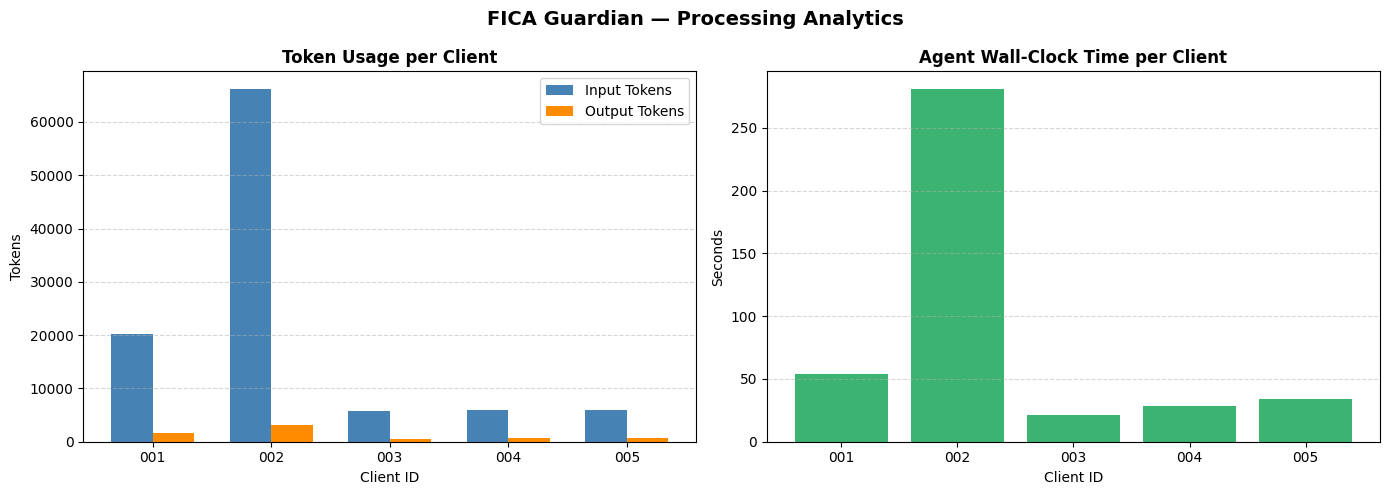

Analytics chart saved to: ./fica_analytics.png


In [16]:
# ---------------------------------------------------------------------------
# TOKEN USAGE & PERFORMANCE ANALYTICS
#
# Data source: audit_middleware.audit_records populated by KYCAuditMiddleware
#
# Outputs:
#   1. Per-client token breakdown table (input, output, total, LLM served)
#   2. Per-client wall-clock time
#   3. Gate tool latency breakdown
#   4. Aggregate token consumption vs estimated daily Groq quota remaining
#   5. Bar chart: token usage per client
# ---------------------------------------------------------------------------

records = audit_middleware.audit_records

if not records:
    print("No audit records found. Ensure the agent ran with KYCAuditMiddleware attached.")
else:
    # --- Per-Client Summary Table -------------------------------------------
    summary_rows = []
    for rec in records:
        models_used = list({mc["model"] for mc in rec["model_calls"]})
        summary_rows.append({
            "Client ID"         : rec["client_id"],
            "Model Calls"       : len(rec["model_calls"]),
            "Input Tokens"      : rec["total_input_tokens"],
            "Output Tokens"     : rec["total_output_tokens"],
            "Total Tokens"      : rec["total_tokens"],
            "Wall Clock (s)"    : rec["wall_clock_sec"],
            "LLM Served"        : ", ".join(models_used) if models_used else "unknown",
        })

    df_summary = pd.DataFrame(summary_rows)
    print("=== Per-Client Token Usage ===")
    print(df_summary.to_string(index=False))

    # --- Aggregate Stats ----------------------------------------------------
    total_tokens_consumed   = df_summary["Total Tokens"].sum()
    groq_daily_limit        = 500_000   # Conservative free-tier daily limit
    estimated_remaining     = max(0, groq_daily_limit - total_tokens_consumed)
    avg_tokens_per_client   = df_summary["Total Tokens"].mean()

    print(f"\n=== Aggregate Token Analytics ===")
    print(f"  Total tokens consumed    : {total_tokens_consumed:,}")
    print(f"  Groq daily quota (est.)  : {groq_daily_limit:,}")
    print(f"  Estimated quota remaining: {estimated_remaining:,}")
    print(f"  Avg tokens per client    : {avg_tokens_per_client:,.0f}")
    print(f"  Estimated clients/day    : {int(groq_daily_limit / avg_tokens_per_client) if avg_tokens_per_client > 0 else 'N/A'}")

    # --- Gate Tool Latency --------------------------------------------------
    tool_rows = []
    for rec in records:
        for tc in rec["tool_calls"]:
            tool_rows.append({
                "Client ID" : rec["client_id"],
                "Tool"      : tc["tool"],
                "Verdict"   : tc["verdict"],
                "Latency ms": tc["latency_ms"],
            })

    if tool_rows:
        df_tools = pd.DataFrame(tool_rows)
        print(f"\n=== Gate Tool Latency (ms) ===")
        print(df_tools.groupby("Tool")["Latency ms"].agg(["mean", "max", "min"]).round(1).to_string())

    # --- Bar Chart: Token Usage Per Client ----------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Token breakdown per client
    clients = df_summary["Client ID"].astype(str)
    x       = range(len(clients))
    width   = 0.35

    axes[0].bar([i - width/2 for i in x], df_summary["Input Tokens"],
                width, label="Input Tokens",  color="steelblue")
    axes[0].bar([i + width/2 for i in x], df_summary["Output Tokens"],
                width, label="Output Tokens", color="darkorange")
    axes[0].set_title("Token Usage per Client", fontweight="bold")
    axes[0].set_xlabel("Client ID")
    axes[0].set_ylabel("Tokens")
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(clients)
    axes[0].legend()
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

    # Wall-clock time per client
    axes[1].bar(clients, df_summary["Wall Clock (s)"], color="mediumseagreen")
    axes[1].set_title("Agent Wall-Clock Time per Client", fontweight="bold")
    axes[1].set_xlabel("Client ID")
    axes[1].set_ylabel("Seconds")
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

    plt.suptitle("FICA Guardian — Processing Analytics", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("./fica_analytics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Analytics chart saved to: ./fica_analytics.png")

## Section 9: Test Harness Verification

In [17]:
# ---------------------------------------------------------------------------
# TEST HARNESS
#
# Validates that actual agent verdicts match the expected outcomes defined
# in the project specification. Surfaces deviations for investigation.
# ---------------------------------------------------------------------------

EXPECTED_OUTCOMES = {
    "001": {"verdict": "APPROVED"      , "scenario": "Standard — no anomalies"},
    "002": {"verdict": "REJECTED"      , "scenario": "PoR date > 90 days"},
    "003": {"verdict": "CRITICAL_ALERT", "scenario": "Barcode name != OCR name"},
    "004": {"verdict": "FLAG_EDD"      , "scenario": "PEP database hit"},
    "005": {"verdict": "MANUAL_REVIEW" , "scenario": "PO Box on PoR vs physical address"},
}

print("=" * 65)
print("  FICA GUARDIAN — TEST HARNESS RESULTS")
print("=" * 65)
print(f"{'Client':<10} {'Scenario':<35} {'Expected':<17} {'Actual':<17} {'Pass?'}")
print("-" * 65)

all_pass = True
for verdict in all_verdicts:
    cid      = verdict.client_id
    expected = EXPECTED_OUTCOMES.get(cid, {}).get("verdict", "UNKNOWN")
    scenario = EXPECTED_OUTCOMES.get(cid, {}).get("scenario", "")
    actual   = verdict.final_verdict
    passed   = (actual == expected)
    if not passed:
        all_pass = False
    status_str = "PASS" if passed else "FAIL"
    print(f"{cid:<10} {scenario:<35} {expected:<17} {actual:<17} {status_str}")

print("-" * 65)
print(f"Overall result: {'ALL TESTS PASSED' if all_pass else 'ONE OR MORE TESTS FAILED'}")
print("=" * 65)

  FICA GUARDIAN — TEST HARNESS RESULTS
Client     Scenario                            Expected          Actual            Pass?
-----------------------------------------------------------------
001        Standard — no anomalies             APPROVED          CRITICAL_ALERT    FAIL
002        PoR date > 90 days                  REJECTED          MANUAL_REVIEW     FAIL
003        Barcode name != OCR name            CRITICAL_ALERT    MANUAL_REVIEW     FAIL
004        PEP database hit                    FLAG_EDD          MANUAL_REVIEW     FAIL
005        PO Box on PoR vs physical address   MANUAL_REVIEW     MANUAL_REVIEW     PASS
-----------------------------------------------------------------
Overall result: ONE OR MORE TESTS FAILED
